# Entropy at smoothed and unsmoothed DMRs

##### Modules

In [1]:
import pandas as pd
import numpy as np
import time
import psutil
import os
import re
from pybedtools import BedTool

import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

##### Fonts & Colors

In [2]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# font size
b = 1
title_size = 18 + b
label_size = 16 + b
tick_size = 12 + b

color_dict = dict(zip(['unsmoothed', 'smoothed', 'modkit'], plt.cm.Dark2.colors[:3]))

##### Inputs

In [3]:
seg_cols = [
    'chrom',
    'start',
    'end',
    'state_name',
    'score',
    'n_sites',
    'a_counts',
    'b_counts',
    'a_mod_percentages',
    'b_mod_percentages',
    'a_frac_modified',
    'b_frac_modified',
    'effect_size',
    'cohen_h', 
    'cohen_h_low',
    'cohen_h_high'
]

ent_cols = [
    'chrom',
    'start',
    'end',
    'region_name',
    'mean_entropy',
    'strand',
    'median_entropy',
    'min_entropy',
    'max_entropy',
    'mean_num_reads',
    'min_num_reads',
    'max_num_reads',
    'successful_window_count',
    'failed_window_count',
]

In [4]:
DIR1 = '/scratch/eger/projects/MethSmoothEval/tissues/modkit/entropy/DMR_entropy'

In [5]:
sample_dict = {'hg002_blood': 'Blood1_5kHz',
              'Bulk_FC_Control_02': 'Brain1_5kHz',
              'PPMI_3404': 'Blood2_4kHz',
              'HBCC_81951_FTX': 'Brain2_4kHz',
              'HBCC_82044_FTX': 'Brain3_4kHz'}

### 5kHz samples

smoothed 0.91835675
unsmoothed 0.84231365


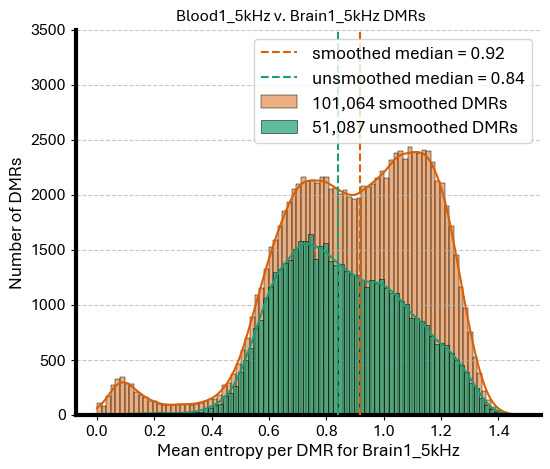

In [6]:
sample = 'Bulk_FC_Control_02'
comparison = 'hg002_blood_v_Bulk_FC_Control_02'
comparison_name = 'Blood1_5kHz v. Brain1_5kHz'

# get entropy for DMRs
fname1 = os.path.join(DIR1, sample, comparison+'.dss_smoothed_dmrs', 'regions.bed')
fname2 = os.path.join(DIR1, sample, comparison+'.dss_unsmoothed_dmrs', 'regions.bed')

smooth_df = pd.read_csv(fname1, sep='\t', header=None, names=ent_cols)
unsmooth_df = pd.read_csv(fname2, sep='\t', header=None, names=ent_cols)

# combine DMRs
smooth_df['type']='smoothed'
unsmooth_df['type']='unsmoothed'

dss_dmr_df = pd.concat([
    smooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']], 
    unsmooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']]
    ], ignore_index=True)

# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="mean_entropy",
    color=color_dict["smoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="mean_entropy",
    color=color_dict["unsmoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['mean_entropy'].median()
    print(region_type, median)
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median:.2f}'
    )

# limits and labels
# ax.set_xlim(-10, 2000)
ax.set_ylim(0, 3500)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Mean entropy per DMR for "+sample_dict[sample], fontsize=tick_size)
ax.set_ylabel("Number of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(comparison_name+' DMRs', y=0.92)

plt.show()

In [8]:
dss_dmr_df

,chrom,start,end,type,region_name,mean_entropy
0,chr1,10470,11239,smoothed,chr1:10469-11300,0.966376
1,chr1,12753,12782,smoothed,chr1:12426-12807,0.993366
2,chr1,51587,52053,smoothed,chr1:50864-52474,0.810382
3,chr1,136863,137023,smoothed,chr1:136778-137071,0.895744
4,chr1,175316,175403,smoothed,chr1:174245-175430,1.024369
...,...,...,...,...,...,...
152146,chrY,26121698,26121759,unsmoothed,chrY:26121593-26122051,0.743694
152147,chrY,26152987,26153121,unsmoothed,chrY:26152691-26153831,0.772439
152148,chrY,26315614,26315669,unsmoothed,chrY:26315607-26315677,1.063574
152149,chrY,26315765,26315871,unsmoothed,chrY:26315733-26315883,0.924512


smoothed 0.91835675
unsmoothed 0.84231365


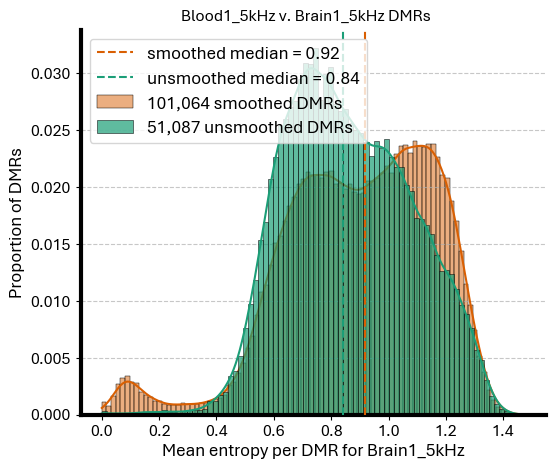

In [46]:
sample = 'Bulk_FC_Control_02'
comparison = 'hg002_blood_v_Bulk_FC_Control_02'
comparison_name = 'Blood1_5kHz v. Brain1_5kHz'

# get entropy for DMRs
fname1 = os.path.join(DIR1, sample, comparison+'.dss_smoothed_dmrs', 'regions.bed')
fname2 = os.path.join(DIR1, sample, comparison+'.dss_unsmoothed_dmrs', 'regions.bed')

smooth_df = pd.read_csv(fname1, sep='\t', header=None, names=ent_cols)
unsmooth_df = pd.read_csv(fname2, sep='\t', header=None, names=ent_cols)

# combine DMRs
smooth_df['type']='smoothed'
unsmooth_df['type']='unsmoothed'

dss_dmr_df = pd.concat([
    smooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']], 
    unsmooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']]
    ], ignore_index=True)

# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="mean_entropy",
    color=color_dict["smoothed"],
    stat="proportion",
    common_norm=False,
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="mean_entropy",
    color=color_dict["unsmoothed"],
    stat="proportion",
    common_norm=False,
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['mean_entropy'].median()
    print(region_type, median)
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median:.2f}'
    )

# limits and labels
# ax.set_xlim(-10, 2000)
#ax.set_ylim(0, 3500)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Mean entropy per DMR for "+sample_dict[sample], fontsize=tick_size)
ax.set_ylabel("Proportion of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(comparison_name+' DMRs', y=0.92)

plt.show()

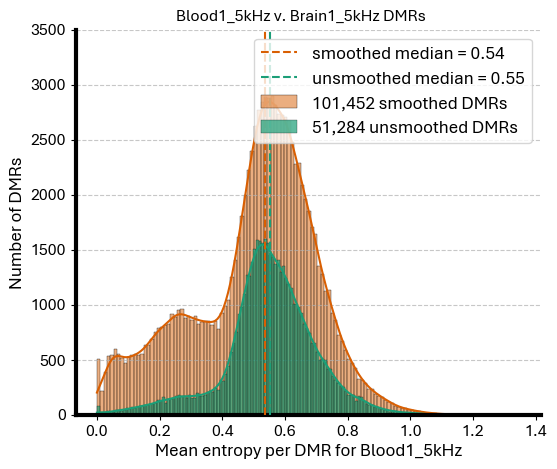

In [45]:
sample = 'hg002_blood'
comparison = 'hg002_blood_v_Bulk_FC_Control_02'
comparison_name = 'Blood1_5kHz v. Brain1_5kHz'

# get entropy for DMRs
fname1 = os.path.join(DIR1, sample, comparison+'.dss_smoothed_dmrs', 'regions.bed')
fname2 = os.path.join(DIR1, sample, comparison+'.dss_unsmoothed_dmrs', 'regions.bed')

smooth_df = pd.read_csv(fname1, sep='\t', header=None, names=ent_cols)
unsmooth_df = pd.read_csv(fname2, sep='\t', header=None, names=ent_cols)

# combine DMRs
smooth_df['type']='smoothed'
unsmooth_df['type']='unsmoothed'

dss_dmr_df = pd.concat([
    smooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']], 
    unsmooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']]
    ], ignore_index=True)

# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="mean_entropy",
    color=color_dict["smoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="mean_entropy",
    color=color_dict["unsmoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['mean_entropy'].median()
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median:.2f}'
    )

# limits and labels
# ax.set_xlim(-10, 2000)
ax.set_ylim(0, 3500)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Mean entropy per DMR for "+sample_dict[sample], fontsize=tick_size)
ax.set_ylabel("Number of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(comparison_name+' DMRs', y=0.92)

plt.show()

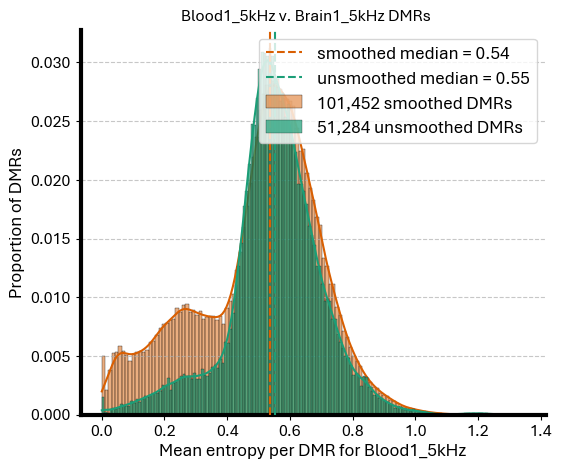

In [48]:
sample = 'hg002_blood'
comparison = 'hg002_blood_v_Bulk_FC_Control_02'
comparison_name = 'Blood1_5kHz v. Brain1_5kHz'

# get entropy for DMRs
fname1 = os.path.join(DIR1, sample, comparison+'.dss_smoothed_dmrs', 'regions.bed')
fname2 = os.path.join(DIR1, sample, comparison+'.dss_unsmoothed_dmrs', 'regions.bed')

smooth_df = pd.read_csv(fname1, sep='\t', header=None, names=ent_cols)
unsmooth_df = pd.read_csv(fname2, sep='\t', header=None, names=ent_cols)

# combine DMRs
smooth_df['type']='smoothed'
unsmooth_df['type']='unsmoothed'

dss_dmr_df = pd.concat([
    smooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']], 
    unsmooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']]
    ], ignore_index=True)

# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="mean_entropy",
    color=color_dict["smoothed"],
    stat="proportion",
    common_norm=False,
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="mean_entropy",
    color=color_dict["unsmoothed"],
    stat="proportion",
    common_norm=False,
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['mean_entropy'].median()
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median:.2f}'
    )

# limits and labels
# ax.set_xlim(-10, 2000)
#ax.set_ylim(0, 3500)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Mean entropy per DMR for "+sample_dict[sample], fontsize=tick_size)
ax.set_ylabel("Proportion of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(comparison_name+' DMRs', y=0.92)

plt.show()

### 4kHz samples

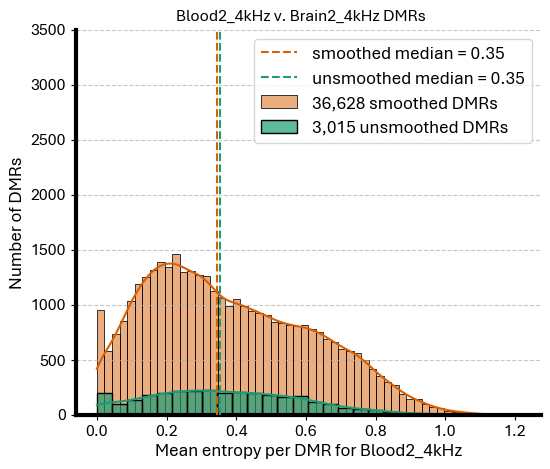

In [40]:
sample = 'PPMI_3404'
comparison = 'PPMI_3404_v_HBCC_81951_FTX'
comparison_name = 'Blood2_4kHz v. Brain2_4kHz'

# get entropy for DMRs
fname1 = os.path.join(DIR1, sample, comparison+'.dss_smoothed_dmrs', 'regions.bed')
fname2 = os.path.join(DIR1, sample, comparison+'.dss_unsmoothed_dmrs', 'regions.bed')

smooth_df = pd.read_csv(fname1, sep='\t', header=None, names=ent_cols)
unsmooth_df = pd.read_csv(fname2, sep='\t', header=None, names=ent_cols)

# combine DMRs
smooth_df['type']='smoothed'
unsmooth_df['type']='unsmoothed'

dss_dmr_df = pd.concat([
    smooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']], 
    unsmooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']]
    ], ignore_index=True)

# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="mean_entropy",
    color=color_dict["smoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="mean_entropy",
    color=color_dict["unsmoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['mean_entropy'].median()
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median:.2f}'
    )

# limits and labels
# ax.set_xlim(-10, 2000)
ax.set_ylim(0, 3500)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Mean entropy per DMR for "+sample_dict[sample], fontsize=tick_size)
ax.set_ylabel("Number of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(comparison_name+' DMRs', y=0.92)

plt.show()

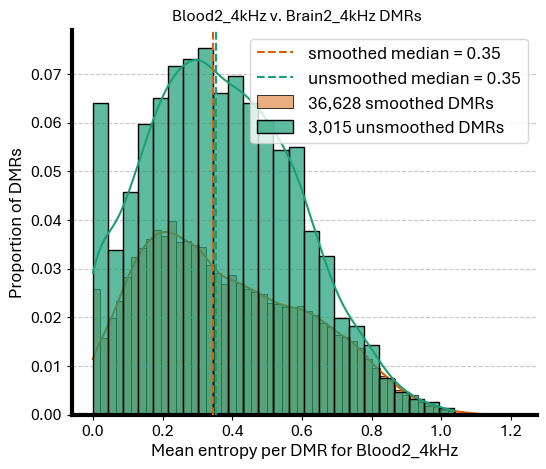

In [51]:
sample = 'PPMI_3404'
comparison = 'PPMI_3404_v_HBCC_81951_FTX'
comparison_name = 'Blood2_4kHz v. Brain2_4kHz'

# get entropy for DMRs
fname1 = os.path.join(DIR1, sample, comparison+'.dss_smoothed_dmrs', 'regions.bed')
fname2 = os.path.join(DIR1, sample, comparison+'.dss_unsmoothed_dmrs', 'regions.bed')

smooth_df = pd.read_csv(fname1, sep='\t', header=None, names=ent_cols)
unsmooth_df = pd.read_csv(fname2, sep='\t', header=None, names=ent_cols)

# combine DMRs
smooth_df['type']='smoothed'
unsmooth_df['type']='unsmoothed'

dss_dmr_df = pd.concat([
    smooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']], 
    unsmooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']]
    ], ignore_index=True)

# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="mean_entropy",
    color=color_dict["smoothed"],
    stat="proportion",
    common_norm=False,
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="mean_entropy",
    color=color_dict["unsmoothed"],
    stat="proportion",
    common_norm=False,
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['mean_entropy'].median()
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median:.2f}'
    )

# limits and labels
# ax.set_xlim(-10, 2000)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Mean entropy per DMR for "+sample_dict[sample], fontsize=tick_size)
ax.set_ylabel("Proportion of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(comparison_name+' DMRs', y=0.92)

plt.show()

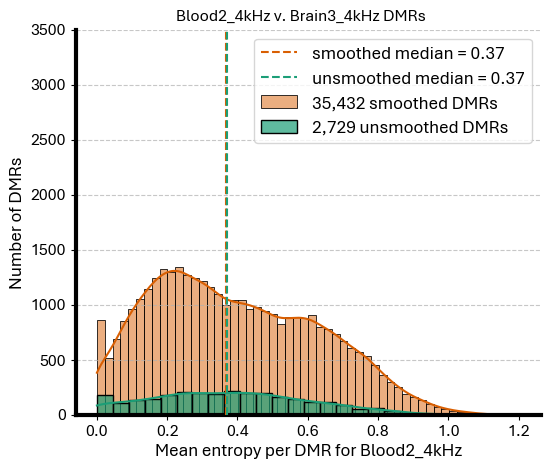

In [41]:
sample = 'PPMI_3404'
comparison = 'PPMI_3404_v_HBCC_82044_FTX'
comparison_name = 'Blood2_4kHz v. Brain3_4kHz'

# get entropy for DMRs
fname1 = os.path.join(DIR1, sample, comparison+'.dss_smoothed_dmrs', 'regions.bed')
fname2 = os.path.join(DIR1, sample, comparison+'.dss_unsmoothed_dmrs', 'regions.bed')

smooth_df = pd.read_csv(fname1, sep='\t', header=None, names=ent_cols)
unsmooth_df = pd.read_csv(fname2, sep='\t', header=None, names=ent_cols)

# combine DMRs
smooth_df['type']='smoothed'
unsmooth_df['type']='unsmoothed'

dss_dmr_df = pd.concat([
    smooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']], 
    unsmooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']]
    ], ignore_index=True)

# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="mean_entropy",
    color=color_dict["smoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="mean_entropy",
    color=color_dict["unsmoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['mean_entropy'].median()
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median:.2f}'
    )

# limits and labels
# ax.set_xlim(-10, 2000)
ax.set_ylim(0, 3500)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Mean entropy per DMR for "+sample_dict[sample], fontsize=tick_size)
ax.set_ylabel("Number of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(comparison_name+' DMRs', y=0.92)

plt.show()

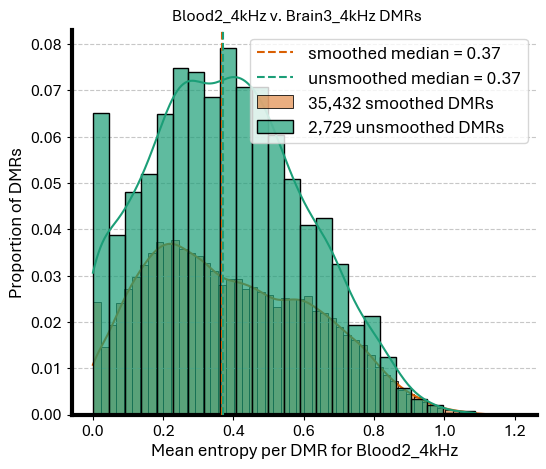

In [52]:
sample = 'PPMI_3404'
comparison = 'PPMI_3404_v_HBCC_82044_FTX'
comparison_name = 'Blood2_4kHz v. Brain3_4kHz'

# get entropy for DMRs
fname1 = os.path.join(DIR1, sample, comparison+'.dss_smoothed_dmrs', 'regions.bed')
fname2 = os.path.join(DIR1, sample, comparison+'.dss_unsmoothed_dmrs', 'regions.bed')

smooth_df = pd.read_csv(fname1, sep='\t', header=None, names=ent_cols)
unsmooth_df = pd.read_csv(fname2, sep='\t', header=None, names=ent_cols)

# combine DMRs
smooth_df['type']='smoothed'
unsmooth_df['type']='unsmoothed'

dss_dmr_df = pd.concat([
    smooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']], 
    unsmooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']]
    ], ignore_index=True)

# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="mean_entropy",
    color=color_dict["smoothed"],
    stat="proportion",
    common_norm=False,
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="mean_entropy",
    color=color_dict["unsmoothed"],
    stat="proportion",
    common_norm=False,
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['mean_entropy'].median()
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median:.2f}'
    )

# limits and labels
# ax.set_xlim(-10, 2000)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Mean entropy per DMR for "+sample_dict[sample], fontsize=tick_size)
ax.set_ylabel("Proportion of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(comparison_name+' DMRs', y=0.92)

plt.show()

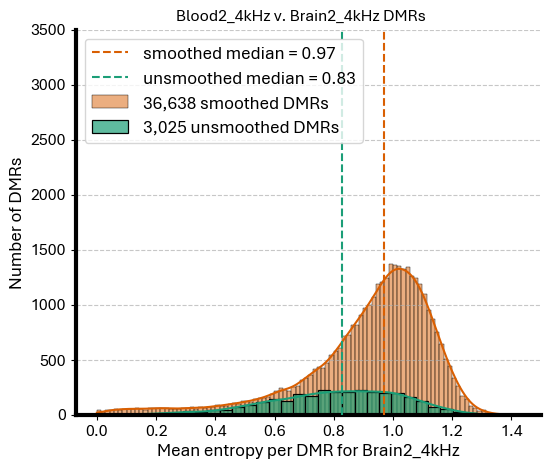

In [42]:
sample = 'HBCC_81951_FTX'
comparison = 'PPMI_3404_v_HBCC_81951_FTX'
comparison_name = 'Blood2_4kHz v. Brain2_4kHz'

# get entropy for DMRs
fname1 = os.path.join(DIR1, sample, comparison+'.dss_smoothed_dmrs', 'regions.bed')
fname2 = os.path.join(DIR1, sample, comparison+'.dss_unsmoothed_dmrs', 'regions.bed')

smooth_df = pd.read_csv(fname1, sep='\t', header=None, names=ent_cols)
unsmooth_df = pd.read_csv(fname2, sep='\t', header=None, names=ent_cols)

# combine DMRs
smooth_df['type']='smoothed'
unsmooth_df['type']='unsmoothed'

dss_dmr_df = pd.concat([
    smooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']], 
    unsmooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']]
    ], ignore_index=True)

# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="mean_entropy",
    color=color_dict["smoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="mean_entropy",
    color=color_dict["unsmoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['mean_entropy'].median()
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median:.2f}'
    )

# limits and labels
# ax.set_xlim(-10, 2000)
ax.set_ylim(0, 3500)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Mean entropy per DMR for "+sample_dict[sample], fontsize=tick_size)
ax.set_ylabel("Number of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(comparison_name+' DMRs', y=0.92)

plt.show()

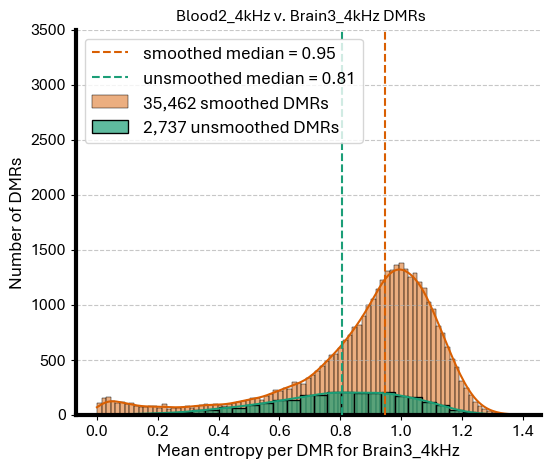

In [44]:
sample = 'HBCC_82044_FTX'
comparison = 'PPMI_3404_v_HBCC_82044_FTX'
comparison_name = 'Blood2_4kHz v. Brain3_4kHz'

# get entropy for DMRs
fname1 = os.path.join(DIR1, sample, comparison+'.dss_smoothed_dmrs', 'regions.bed')
fname2 = os.path.join(DIR1, sample, comparison+'.dss_unsmoothed_dmrs', 'regions.bed')

smooth_df = pd.read_csv(fname1, sep='\t', header=None, names=ent_cols)
unsmooth_df = pd.read_csv(fname2, sep='\t', header=None, names=ent_cols)

# combine DMRs
smooth_df['type']='smoothed'
unsmooth_df['type']='unsmoothed'

dss_dmr_df = pd.concat([
    smooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']], 
    unsmooth_df[['chrom', 'start', 'end','type', 'region_name', 'mean_entropy']]
    ], ignore_index=True)

# initialize figure
fig, ax = plt.subplots(figsize=(6, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="mean_entropy",
    color=color_dict["smoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="mean_entropy",
    color=color_dict["unsmoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['mean_entropy'].median()
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median:.2f}'
    )

# limits and labels
# ax.set_xlim(-10, 2000)
ax.set_ylim(0, 3500)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Mean entropy per DMR for "+sample_dict[sample], fontsize=tick_size)
ax.set_ylabel("Number of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(comparison_name+' DMRs', y=0.92)

plt.show()